- Name : Ashlesha Tayade
- PRN  : 260240128008
---------------------------------
- Name : Ruchika Gaikwad
- PRN  : 260240128036

# Image Processing with Neural Network
## A06: Group Assignment


##  Convolutional Neural Network (CNN)

- Flowers Dataset


In [ ]:
###-----------------
### Import libraries
###-----------------

from pathlib import Path  # Import Path for file system path operations and management
import numpy as np  # Import NumPy for numerical computations and array operations
import pandas as pd  # Import Pandas for data manipulation and analysis with DataFrames
import matplotlib.pyplot as plt  # Import Matplotlib for creating static, interactive visualizations
import seaborn as sns  # Import Seaborn for statistical data visualization built on Matplotlib

from sklearn.model_selection import train_test_split  # Import function to split dataset into training and testing subsets
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay, f1_score  # Import function to calculate various metric

from collections.abc import Callable  # Type hinting callable objects/functions
from typing import Literal  # Literal type hints to restrict variable values

from sklearn.preprocessing import StandardScaler  # Import for standardizing features (zero mean, unit variance)

# from utils.helper import fn_plot_tf_hist, fn_plot_confusion_matrix, fn_plot_label# Custom utility

import tensorflow as tf
import os

In [ ]:
###----------------------
### Some basic parameters
###----------------------

inpDir = Path('..')  # ← fix this line
outDir = Path('..') / 'output'
modelDir = Path('..') / 'models'
subDir = 'flower_photos'
altName = 'cnn_base'

RANDOM_STATE = 24 # for initialization ----- REMEMBER: to remove at the time of promotion to production
tf.random.set_seed(RANDOM_STATE) # setting for Tensorflow as well

TEST_SIZE = 0.2

ALPHA = 0.001
EPOCHS = 100 # number of cycles to run
PATIENCE = 20
LR_PATIENCE = 10
FACTOR_LR = 0.5
BATCH_SIZE = 16 # inline of Training Rows being 60000
IMG_HEIGHT = 190
IMG_WIDTH = 190


# Set parameters for decoration of plots
params = {'legend.fontsize' : 'large',
          'figure.figsize'  : (15,6),
          'axes.labelsize'  : 'x-large',
          'axes.titlesize'  :'x-large',
          'xtick.labelsize' :'large',
          'ytick.labelsize' :'large',
         }

CMAP = plt.cm.coolwarm

plt.rcParams.update(params) # update rcParams

plt.style.use('seaborn-v0_8-darkgrid') # plt.style.use('ggplot')

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## Basic Hygiene

In [ ]:
###------------------
### Memory Management
###------------------

physical_devices = tf.config.list_physical_devices('GPU')

if len(physical_devices) > 0:
    tf.config.experimental.set_memory_growth(physical_devices[0], True)
    print (physical_devices)
else:
    print ('Error: No GPU device found')

[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


## Load Dataset

Images are under flower_photos

     |- daisy
     |- dandelion
     |- roses
     |- sunflowers
     |- tulips

In [ ]:
# This cell is being removed as its functionality is superseded by cell dau7hm873w1G and it uses an incorrect URL.

In [ ]:
import pathlib
import os
import tarfile
import shutil # Import shutil for rmtree

# Define the expected names and paths
subDir = 'flower_photos' # This variable is already defined in IuGq-5TQj2JP
archive_filename = "flower_photos.tgz"
dataset_url = "https://storage.googleapis.com/download.tensorflow.org/example_images/flower_photos.tgz"

# Define the root Keras cache directory and the dataset directory
# pathlib.Path.home() resolves to /root in Colab
keras_root_dir = pathlib.Path.home() / '.keras'
keras_dataset_dir = keras_root_dir / 'datasets'

# Expected final data directory where the images should reside
expected_data_dir = keras_dataset_dir / subDir # e.g., /root/.keras/datasets/flower_photos
# Expected path for the downloaded archive file
expected_archive_path = keras_dataset_dir / archive_filename # e.g., /root/.keras/datasets/flower_photos.tgz

print(f"Expected Keras dataset directory: {keras_dataset_dir}")
print(f"Expected final data_dir: {expected_data_dir}")
print(f"Expected archive path: {expected_archive_path}")

# Ensure the dataset directory exists for extraction
keras_dataset_dir.mkdir(parents=True, exist_ok=True)

# Clean up any potentially corrupted previous downloads/extractions
if expected_data_dir.exists():
    print(f"Found existing data_dir: {expected_data_dir}. Cleaning up...")
    shutil.rmtree(expected_data_dir)
if expected_archive_path.exists():
    print(f"Found existing archive: {expected_archive_path}. Deleting...")
    expected_archive_path.unlink()

# 1. Download the archive file using tf.keras.utils.get_file, but DO NOT untar it automatically.
print(f"Downloading {dataset_url} to {expected_archive_path}...")
downloaded_archive_path_str = tf.keras.utils.get_file(
    origin=dataset_url,
    fname=archive_filename,        # Saves as 'flower_photos.tgz'
    cache_dir=keras_dataset_dir,   # Explicitly saves to ~/.keras/datasets/
    untar=False                    # Prevent automatic untarring
)

downloaded_archive_path = pathlib.Path(downloaded_archive_path_str)
print(f"Actual downloaded archive path returned by get_file: {downloaded_archive_path}")
print(f"Does downloaded archive exist: {downloaded_archive_path.exists()}")
if not downloaded_archive_path.exists():
    print("ERROR: Archive file was not downloaded correctly.")
    raise FileNotFoundError("Downloaded archive not found.")
print(f"Size of downloaded archive: {downloaded_archive_path.stat().st_size} bytes")

# 2. Manually extract the archive using tarfile
print(f"Extracting {downloaded_archive_path} to {keras_dataset_dir}...")
try:
    with tarfile.open(downloaded_archive_path, 'r:gz') as tar:
        # Check if the archive contains a top-level 'flower_photos' folder
        members = tar.getnames()
        contains_top_level_folder = any(m.startswith(subDir + '/') for m in members) or subDir in members

        if not contains_top_level_folder:
            print(f"WARNING: Archive does not seem to contain a top-level '{subDir}' folder directly. Extraction might place contents directly into target_dir.")

        tar.extractall(path=keras_dataset_dir, filter='data') # Added filter='data' to address DeprecationWarning
    print("Archive extracted successfully.")
except tarfile.ReadError as e:
    print(f"ERROR: Could not open or extract archive. It might be corrupted or not a valid gzip file: {e}")
    if downloaded_archive_path.exists():
        downloaded_archive_path.unlink()
    raise # Re-raise to stop execution, as data is not available
except Exception as e:
    print(f"An unexpected error occurred during extraction: {e}")
    raise

# 3. Set data_dir to the expected final path
data_dir = expected_data_dir

# Final verification
print("\nFinal data_dir for image loading:", data_dir)
print("Final data_dir exists:", data_dir.exists())

if data_dir.exists() and data_dir.is_dir():
    print("\nContents of final data_dir (first 5 items):")
    try:
        for i, item in enumerate(data_dir.iterdir()):
            print(f"  {item.name} (Is Directory: {item.is_dir()})")
            if i >= 4: # Print up to 5 items to keep output concise
                break
    except Exception as e:
        print(f"Could not list directory contents (e.g., permissions issue or not a directory): {e}")
else:
    print("\nCRITICAL ERROR: Final data_dir does not exist or is not a directory after extraction.")
    raise FileNotFoundError(f"Dataset directory not found: {data_dir}")


Expected Keras dataset directory: /root/.keras/datasets
Expected final data_dir: /root/.keras/datasets/flower_photos
Expected archive path: /root/.keras/datasets/flower_photos.tgz
Found existing data_dir: /root/.keras/datasets/flower_photos. Cleaning up...
Actual downloaded archive path returned by get_file: /root/.keras/datasets/datasets/flower_photos.tgz
Does downloaded archive exist: True
Size of downloaded archive: 228813984 bytes
Extracting /root/.keras/datasets/datasets/flower_photos.tgz to /root/.keras/datasets...
Archive extracted successfully.

Final data_dir for image loading: /root/.keras/datasets/flower_photos
Final data_dir exists: True

Contents of final data_dir (first 5 items):
  tulips (Is Directory: True)
  sunflowers (Is Directory: True)
  LICENSE.txt (Is Directory: False)
  roses (Is Directory: True)
  dandelion (Is Directory: True)


In [ ]:
# List only directories
print(f"data_dir in Y2LmJ0Q8nBPe: {data_dir}")
directories = [item for item in data_dir.iterdir() if item.is_dir()]
directories


data_dir in Y2LmJ0Q8nBPe: /root/.keras/datasets/flower_photos


[PosixPath('/root/.keras/datasets/flower_photos/tulips'),
 PosixPath('/root/.keras/datasets/flower_photos/sunflowers'),
 PosixPath('/root/.keras/datasets/flower_photos/roses'),
 PosixPath('/root/.keras/datasets/flower_photos/dandelion'),
 PosixPath('/root/.keras/datasets/flower_photos/daisy')]

In [ ]:
train_ds = tf.keras.utils.image_dataset_from_directory(
    data_dir,
    validation_split=TEST_SIZE,
    subset='training',
    seed=RANDOM_STATE,
    image_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE)

test_ds = tf.keras.utils.image_dataset_from_directory(
    data_dir,
    validation_split=TEST_SIZE,
    subset='validation',
    seed=RANDOM_STATE,
    image_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE)

Found 3670 files belonging to 5 classes.
Using 2936 files for training.
Found 3670 files belonging to 5 classes.
Using 734 files for validation.


In [ ]:
class_names = train_ds.class_names
num_classes = len(class_names)
print('total ', num_classes, class_names)

total  5 ['daisy', 'dandelion', 'roses', 'sunflowers', 'tulips']


In [ ]:
# is it picking class names
class_names = train_ds.class_names
class_names

['daisy', 'dandelion', 'roses', 'sunflowers', 'tulips']

In [ ]:
AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.cache().shuffle(1000).prefetch(buffer_size=AUTOTUNE)
test_ds  = test_ds.cache().prefetch(buffer_size=AUTOTUNE)

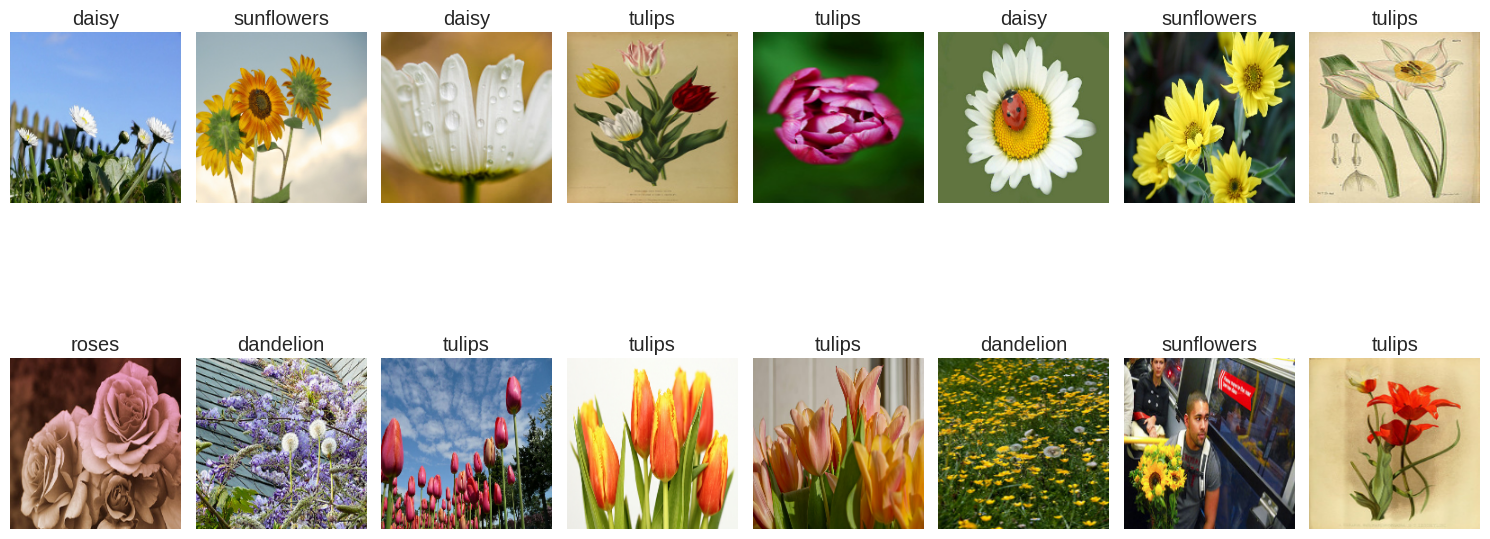

In [ ]:
plt.figure(figsize=(15,8))

for images, labels in train_ds.take(1):
    for i in range (BATCH_SIZE):
        plt.subplot(int(BATCH_SIZE/8), 8, i +1)
        plt.grid(False)
        plt.imshow(images[i].numpy().astype('uint8'))
        plt.title(class_names[labels[i]])
        plt.axis('off')
    plt.tight_layout()
plt.show()

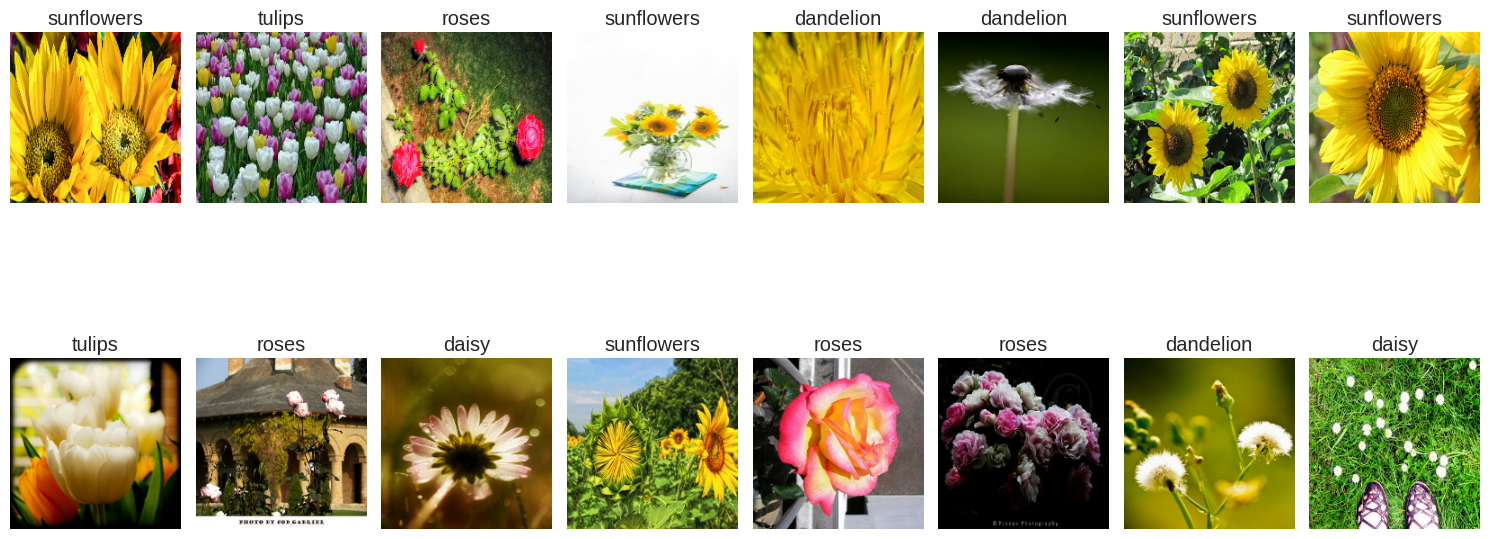

In [ ]:
plt.figure(figsize=(15,8))

for images, labels in test_ds.take(1): # get me one batch

    for i in range (BATCH_SIZE): # loop over batch

        plt.subplot(int(BATCH_SIZE/8), 8, i +1) # access the axis

        plt.grid(False) # no to grid

        plt.imshow(images[i].numpy().astype('uint8')) # show image convert to numpy and int

        plt.title(class_names[labels[i]])

        plt.axis('off')

    plt.tight_layout()

plt.show()

In [ ]:
input_shape = (IMG_HEIGHT, IMG_WIDTH, 3)
input_shape

(190, 190, 3)

### Random Zoom

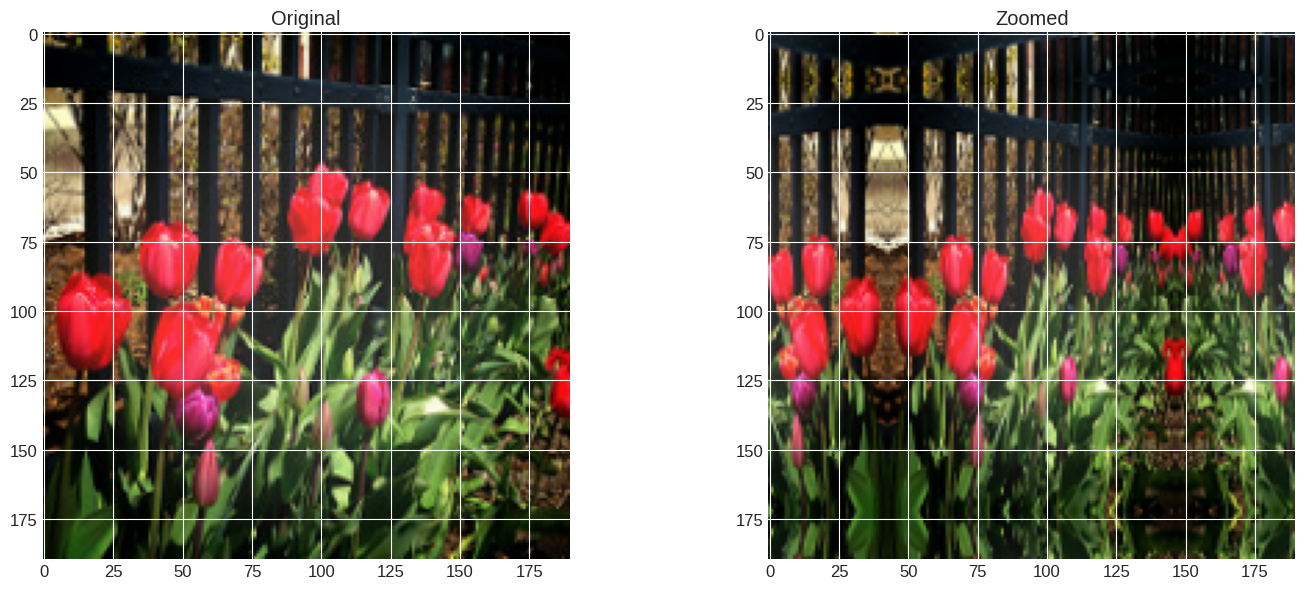

In [ ]:
zoom_layer = tf.keras.layers.RandomZoom(height_factor = (-0.2, 1),
                                        width_factor=(-0.2, 1),
                                        fill_mode='reflect',
                                        interpolation='bilinear',
                                        seed=RANDOM_STATE
                                    )

plt.figure()
num_img = 1
for images, labels in train_ds.take(1):
    out_images = zoom_layer(images)
    plt.subplot(1,2,1)
    plt.title('Original')
    plt.imshow(images[num_img].numpy().astype('uint8'))

    plt.subplot(1,2,2)
    plt.title('Zoomed')
    plt.imshow(out_images[num_img].numpy().astype('uint8'))
    plt.tight_layout()

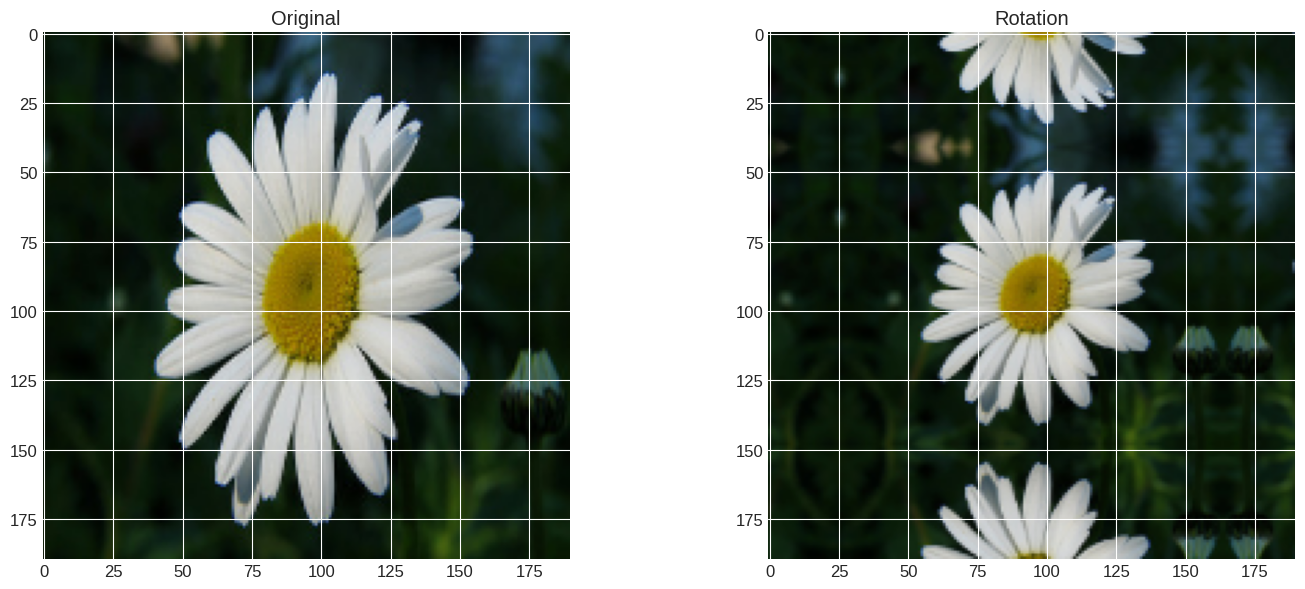

In [ ]:
rot_layer = tf.keras.layers.RandomRotation(factor = (-0.5, 0.5),
                                        seed=RANDOM_STATE
                                    )

plt.figure()
num_img = 1
for images, labels in train_ds.take(1):
    out_images = zoom_layer(images)
    plt.subplot(1,2,1)
    plt.title('Original')
    plt.imshow(images[num_img].numpy().astype('uint8'))

    plt.subplot(1,2,2)
    plt.title('Rotation')
    plt.imshow(out_images[num_img].numpy().astype('uint8'))
    plt.tight_layout()

In [ ]:
###--------------------------
### Dropout rates
### Only applied in Dense head — NOT in Conv blocks (BatchNorm conflict)
###--------------------------
dor5 = 0.4   # after Dense 1
dor6 = 0.3   # after Dense 2
dor7 = 0.2   # after Dense 3

# L2 regularization for Dense layers
from tensorflow.keras import regularizers
l2_reg = regularizers.l2(1e-4)

# Glorot (Xavier) uniform initializer
krnal_init = tf.keras.initializers.GlorotUniform(seed=RANDOM_STATE)

def build_model(input_shape, num_classes):

    # ── Data Augmentation (active only during training) ──
    data_augmentation = tf.keras.Sequential([
        tf.keras.layers.RandomFlip("horizontal_and_vertical"), # was horizontal only
        tf.keras.layers.RandomRotation(0.2),                   # was 0.1
        tf.keras.layers.RandomZoom(0.2),                       # was 0.1
        tf.keras.layers.RandomTranslation(0.1, 0.1),
        tf.keras.layers.RandomContrast(0.2),                   # NEW — handles lighting variation
        tf.keras.layers.RandomBrightness(0.2),                 # NEW — handles color variation
    ], name='data_augmentation')

    model = tf.keras.Sequential(name='cnn_flowers_v3')
    model.add(tf.keras.layers.Input(shape=input_shape))

    # Augmentation
    model.add(data_augmentation)

    # Normalize pixel values 0-255 → 0-1
    model.add(tf.keras.layers.Rescaling(1./255.))

    # ── Conv Block 1 ──
    model.add(tf.keras.layers.Conv2D(32, (3,3),
                                     kernel_initializer=krnal_init,
                                     padding='same'))
    model.add(tf.keras.layers.BatchNormalization())
    model.add(tf.keras.layers.Activation('swish'))  # ReLU → Swish
    model.add(tf.keras.layers.MaxPool2D())
    # NO Dropout — BatchNorm already regularizes Conv blocks

    # ── Conv Block 2 ──
    model.add(tf.keras.layers.Conv2D(64, (3,3),
                                     kernel_initializer=krnal_init,
                                     padding='same'))
    model.add(tf.keras.layers.BatchNormalization())
    model.add(tf.keras.layers.Activation('swish'))
    model.add(tf.keras.layers.MaxPool2D())

    # ── Conv Block 3 ──
    model.add(tf.keras.layers.Conv2D(128, (3,3),
                                     kernel_initializer=krnal_init,
                                     padding='same'))
    model.add(tf.keras.layers.BatchNormalization())
    model.add(tf.keras.layers.Activation('swish'))
    model.add(tf.keras.layers.MaxPool2D())

    # ── Conv Block 4 ──
    model.add(tf.keras.layers.Conv2D(256, (3,3),
                                     kernel_initializer=krnal_init,
                                     padding='same'))
    model.add(tf.keras.layers.BatchNormalization())
    model.add(tf.keras.layers.Activation('swish'))
    model.add(tf.keras.layers.MaxPool2D())

    # ── Head ──
    model.add(tf.keras.layers.Flatten())

    # Dense 1
    model.add(tf.keras.layers.Dense(512,
                                    kernel_initializer=krnal_init,
                                    kernel_regularizer=l2_reg))  # L2 added
    model.add(tf.keras.layers.BatchNormalization())
    model.add(tf.keras.layers.Activation('elu'))                 # ReLU → ELU
    model.add(tf.keras.layers.Dropout(rate=dor5))

    # Dense 2 — NEW middle layer (smooth 512 → 256 → 128)
    model.add(tf.keras.layers.Dense(256,
                                    kernel_initializer=krnal_init,
                                    kernel_regularizer=l2_reg))
    model.add(tf.keras.layers.BatchNormalization())
    model.add(tf.keras.layers.Activation('elu'))
    model.add(tf.keras.layers.Dropout(rate=dor6))

    # Dense 3
    model.add(tf.keras.layers.Dense(128,
                                    kernel_initializer=krnal_init,
                                    kernel_regularizer=l2_reg))
    model.add(tf.keras.layers.BatchNormalization())
    model.add(tf.keras.layers.Activation('elu'))
    model.add(tf.keras.layers.Dropout(rate=dor7))

    # Output — Softmax (change from_logits=False in compile)
    model.add(tf.keras.layers.Dense(num_classes,
                                    kernel_initializer=krnal_init,
                                    activation='softmax'))       # logits → softmax

    return model

model = build_model(input_shape, num_classes)
model.summary()

Model: "cnn_flowers_v3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ data_augmentation (Sequential)  │ (None, 190, 190, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling_1 (Rescaling)         │ (None, 190, 190, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 190, 190, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 190, 190, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_7 (Activation)       │ (None, 190, 190, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 95, 95, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 95, 95, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_8           │ (None, 95, 95, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_8 (Activation)       │ (None, 95, 95, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 47, 47, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 47, 47, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_9           │ (None, 47, 47, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_9 (Activation)       │ (None, 47, 47, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 23, 23, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 23, 23, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_10          │ (None, 23, 23, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_10 (Activation)      │ (None, 23, 23, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 11, 11, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 30976)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 512)            │    15,860,224 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_11          │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_11 (Activation)      │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 16,419,013 (62.63 MB)

 Trainable params: 16,416,261 (62.62 MB)

 Non-trainable params: 2,752 (10.75 KB)

In [ ]:
loss_fn   = tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True)
optimizer = tf.keras.optimizers.Adam(learning_rate=ALPHA)

model.compile(optimizer=optimizer,
              loss=loss_fn,
              metrics=['accuracy'])

In [ ]:
checkpoint_filepath = modelDir / subDir / 'cnn_flowers.weights.h5'

model_checkpoint_callback = tf.keras.callbacks.ModelCheckpoint(
    filepath=checkpoint_filepath,
    save_weights_only=True,
    monitor='val_loss',
    mode='auto',
    save_best_only=True
)

early_stopping_callback = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=PATIENCE,
    mode='auto',
    restore_best_weights=True
)

reduce_lr_callback = tf.keras.callbacks.ReduceLROnPlateau(
    monitor='val_loss',
    factor=FACTOR_LR,
    patience=LR_PATIENCE,
    min_lr=1e-6,
    verbose=1
)

In [ ]:
# fit network
history = model.fit(
    train_ds,
    epochs=EPOCHS,
    validation_data=test_ds,
    verbose=1,
    callbacks=[early_stopping_callback,
               model_checkpoint_callback,
               reduce_lr_callback]
)

Epoch 1/100


/usr/local/lib/python3.12/dist-packages/keras/src/backend/tensorflow/nn.py:1214: UserWarning: "`sparse_categorical_crossentropy` received `from_logits=True`, but the `output` argument was produced by a Softmax activation and thus does not represent logits. Was this intended?
  output, from_logits = _get_logits(


184/184 ━━━━━━━━━━━━━━━━━━━━ 24s 92ms/step - accuracy: 0.4731 - loss: 1.5633 - val_accuracy: 0.2384 - val_loss: 2.4906 - learning_rate: 0.0010
Epoch 2/100
184/184 ━━━━━━━━━━━━━━━━━━━━ 16s 87ms/step - accuracy: 0.5286 - loss: 1.3811 - val_accuracy: 0.3896 - val_loss: 1.7347 - learning_rate: 0.0010
Epoch 3/100
184/184 ━━━━━━━━━━━━━━━━━━━━ 16s 86ms/step - accuracy: 0.5525 - loss: 1.2950 - val_accuracy: 0.5668 - val_loss: 1.2508 - learning_rate: 0.0010
Epoch 4/100
184/184 ━━━━━━━━━━━━━━━━━━━━ 15s 84ms/step - accuracy: 0.5841 - loss: 1.2237 - val_accuracy: 0.5163 - val_loss: 1.5317 - learning_rate: 0.0010
Epoch 5/100
184/184 ━━━━━━━━━━━━━━━━━━━━ 16s 85ms/step - accuracy: 0.6151 - loss: 1.1872 - val_accuracy: 0.6199 - val_loss: 1.1984 - learning_rate: 0.0010
Epoch 6/100
184/184 ━━━━━━━━━━━━━━━━━━━━ 15s 82ms/step - accuracy: 0.6281 - loss: 1.1465 - val_accuracy: 0.5886 - val_loss: 1.3484 - learning_rate: 0.0010
Epoch 7/100
184/184 ━━━━━━━━━━━━━━━━━━━━ 16s 88ms/step - accuracy: 0.6240 - loss: 

## Evaluation

In [ ]:
loss_df = pd.DataFrame(history.history)
loss_df.head()

,accuracy,loss,val_accuracy,val_loss,learning_rate
0,0.473093,1.563260,0.238420,2.490604,0.001
1,0.528610,1.381114,0.389646,1.734676,0.001
2,0.552452,1.294967,0.566758,1.250847,0.001
3,0.584128,1.223692,0.516349,1.531675,0.001
4,0.615123,1.187238,0.619891,1.198427,0.001


In [ ]:
def fn_plot_tf_hist(hist_df):

    '''
    Args:
        hist_df: a DataFrame with column names accuracy,loss	val_accuracy	val_loss
    '''

    fig, axes = plt.subplots(1,2 , figsize = (15,6))

    # properties  matplotlib.patch.Patch
    props = dict(boxstyle='round', facecolor='aqua', alpha=0.4)
    facecolor = 'cyan'
    fontsize=12
    CMAP = plt.cm.coolwarm

    # Get columns by index to eliminate any column naming error
    y1 = hist_df.columns[0]
    y2 = hist_df.columns[1]
    y3 = hist_df.columns[2]
    y4 = hist_df.columns[3]

    # Where was min loss
    best = hist_df[hist_df[y4] == hist_df[y4].min()]

    ax = axes[0]

    hist_df.plot(y = [y2,y4], ax = ax, colormap=CMAP)


    # little beautification
    txtFmt = "Loss: \n  train: {:6.4f}\n   test: {:6.4f}"
    txtstr = txtFmt.format(hist_df.iloc[-1][y2],
                           hist_df.iloc[-1][y4]) #text to plot

    # place a text box in upper middle in axes coords
    ax.text(0.3, 0.95, txtstr, transform=ax.transAxes, fontsize=fontsize,
            verticalalignment='top', bbox=props)

    # calculate offset for arrow
    y_min = min(hist_df[y2].min(), hist_df[y4].min())
    y_max = max(hist_df[y2].max(), hist_df[y4].max())
    offset = (y_max-y_min)/10.0

    best_idx = best.index.to_numpy()[0]  # Extract first (and only) element as scalar
    best_value = best[y4].to_numpy()[0]   # Extract scalar value

    # Mark arrow at lowest
    ax.annotate(f'Min: {best_value:6.4f}', # text to print
                xy=(best_idx, best_value), # Arrow start
                xytext=(best_idx, best_value + offset), # location of text
                fontsize=fontsize, va='bottom', ha='right',bbox=props, # beautification of text
                arrowprops=dict(facecolor=facecolor, shrink=0.05)) # arrow

    # Draw vertical line at best value
    ax.axvline(x = best_idx, color = 'green', linestyle='-.', lw = 3)

    ax.set_xlabel("Epochs")
    ax.set_ylabel(y2.capitalize())
    ax.set_title('Loss Curve')
    ax.grid(True)
    ax.legend(loc = 'upper left') # model legend to upper left

    ax = axes[1]

    hist_df.plot( y = [y1, y3], ax = ax, colormap=CMAP)

    # little beautification
    txtFmt = "Accuracy: \n  train: {:6.4f}\n  test:  {:6.4f}"
    txtstr = txtFmt.format(hist_df.iloc[-1][y1],
                           hist_df.iloc[-1][y3]) #text to plot

    # place a text box in upper middle in axes coords
    ax.text(0.3, 0.2, txtstr, transform=ax.transAxes, fontsize=fontsize,
            verticalalignment='top', bbox=props)

    # calculate offset for arroe
    y_min = min(hist_df[y1].min(), hist_df[y3].min())
    y_max = max(hist_df[y1].max(), hist_df[y3].max())
    offset = (y_max-y_min)/10.0

    best_value = best[y3].to_numpy()[0]   # Extract scalar value
    # Mark arrow at lowest
    ax.annotate(f'Best: {best_value:6.4f}', # text to print
                xy=(best_idx, best_value), # Arrow start
                xytext=(best_idx, best_value-offset), # location of text
                fontsize=fontsize, va='bottom', ha='right',bbox=props, # beautification of text
                arrowprops=dict(facecolor=facecolor, shrink=0.05)) # arrow


    # Draw vertical line at best value
    ax.axvline(x = best_idx, color = 'green', linestyle='-.', lw = 3)

    ax.set_xlabel("Epochs")
    ax.set_ylabel(y1.capitalize())
    ax.set_title('Accuracy Curve')
    ax.grid(True)
    ax.legend(loc = 'lower left')

    plt.tight_layout()

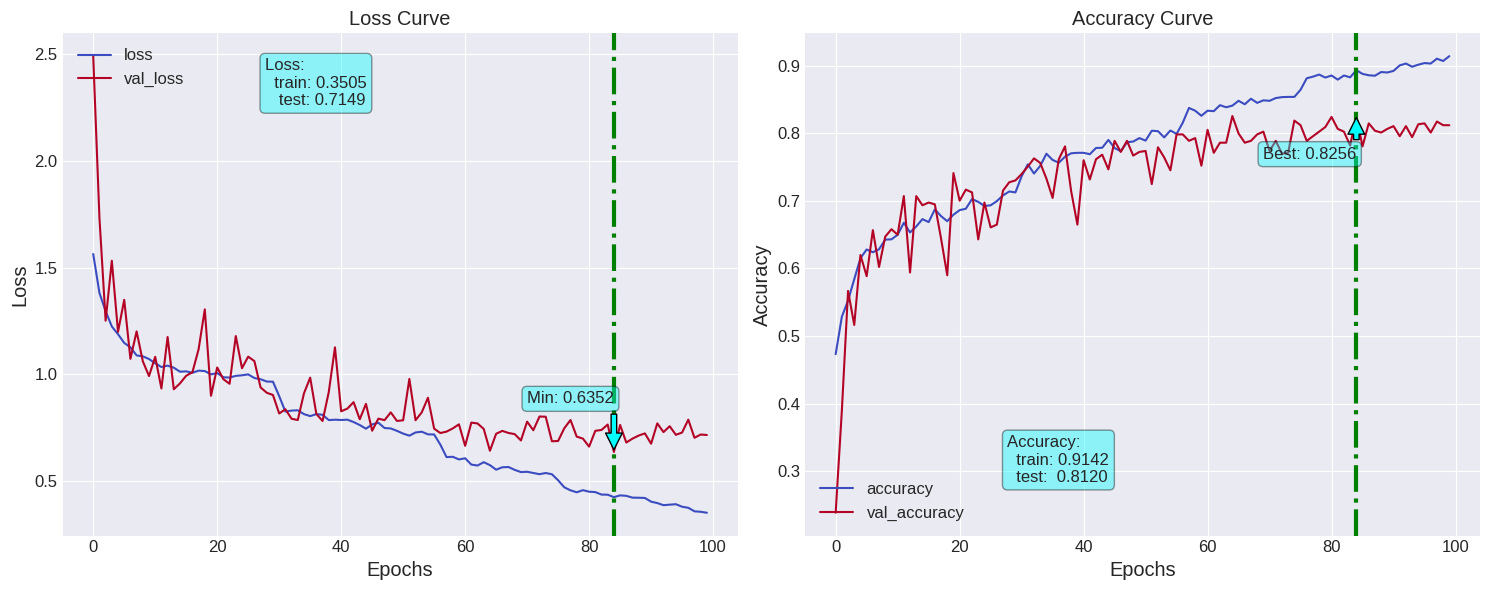

In [ ]:
fn_plot_tf_hist(loss_df)

## Prediction on Train dataset

In [ ]:
y_true, y_pred = [], []

for features, labels in train_ds:
    pred = model(features, training=False)
    pred = pred.numpy().argmax(axis=1)
    y_pred.append(pred)
    y_true.append(labels.numpy())

y_true, y_pred = np.concatenate(y_true), np.concatenate(y_pred)

accuracy_score(y_true, y_pred)

0.8845367847411444

In [ ]:
print(classification_report(y_true, y_pred, target_names=list(class_names)))

              precision    recall  f1-score   support

       daisy       0.92      0.94      0.93       493
   dandelion       0.95      0.89      0.92       723
       roses       0.74      0.90      0.81       525
  sunflowers       0.92      0.96      0.94       561
      tulips       0.89      0.76      0.82       634

    accuracy                           0.88      2936
   macro avg       0.89      0.89      0.88      2936
weighted avg       0.89      0.88      0.88      2936



In [ ]:
def fn_plot_confusion_matrix(y_true, y_pred, labels):
    '''
    Args:
        y_true: Ground Truth
        y_pred : Predictions
        labels : labels in a dictonary
                  {0: 'Goal Keeper',
                  1: 'Defender',
                  2: 'Mid-Fielder',
                  3: 'Forward'}

    '''

    cm  = confusion_matrix(y_true, y_pred)

    if isinstance(labels, dict):
        display_labels = labels.values()
    else:
        display_labels = labels

    disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                                  display_labels=display_labels)

    fig, ax = plt.subplots(figsize = (5,5))

    disp.plot(ax = ax, cmap = 'Blues', xticks_rotation = 'vertical', colorbar=False)

    # Disable the grid
    ax.grid(False)

    title_str = f"F1 Score : {f1_score(y_true, y_pred, average='weighted'):0.5f}"
    ax.set_title(title_str)

    plt.show()

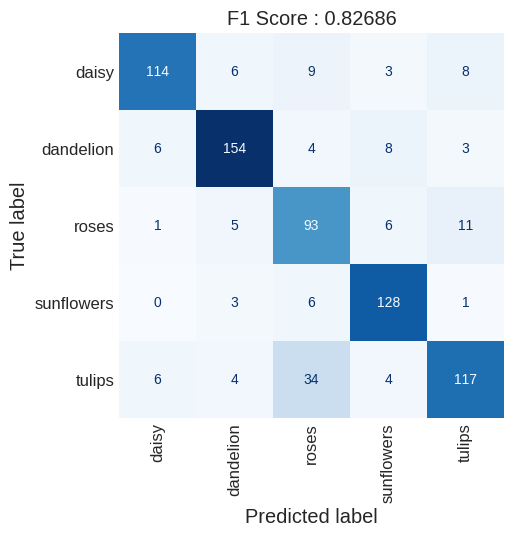

In [ ]:
fn_plot_confusion_matrix( y_true, y_pred, labels=class_names)

## Prediction on Test dataset

In [ ]:
y_true, y_pred = [], []

for features, labels in test_ds:
    pred = model(features, training=False)
    pred = pred.numpy().argmax(axis=1)
    y_pred.append(pred)
    y_true.append(labels.numpy())

y_true, y_pred = np.concatenate(y_true), np.concatenate(y_pred)

accuracy_score(y_true, y_pred)

0.8256130790190735

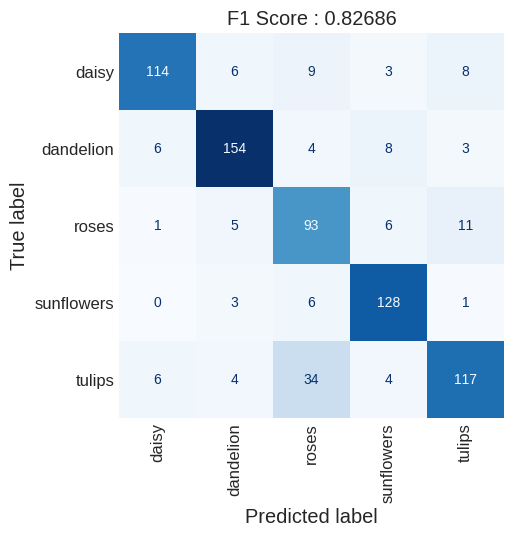

In [ ]:
fn_plot_confusion_matrix( y_true, y_pred, labels=class_names)